Mean Variance Portfolio Optimization (Markowitz)

1 Imports

2 Define Assets

3 Download Data

4 Returns Matrix

5 Expected Returns

6 Covariance Matrix

7 Portfolio Functions

8 Minimum Variance Optimization

9 Portfolio Metrics

10 Random Portfolio Simulation

11 Efficient Frontier

12 Tangency Portfolio

13 Best Random Portfolio

14 Capital Market Line

15 Final Visualization

16 Portfolio Weights

17 Out-of-Sample Backtest

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize
plt.style.use("dark_background")

In [2]:
stocks = [
    "MODEFENCE.NS",
    "CUMMINSIND.NS",
    "POLYCAB.NS",
    "M&M.NS",
    "INDIANB.NS",
    "MON100.NS"
]
data = yf.download(
    stocks,
    start="2022-01-01",
    auto_adjust=True
)["Close"]

print(data.head())
print(data.columns)

[*********************100%***********************]  6 of 6 completed

Ticker      CUMMINSIND.NS  INDIANB.NS      M&M.NS  MODEFENCE.NS   MON100.NS  \
Date                                                                          
2022-01-03     884.158936  126.111023  800.536621           NaN  120.269997   
2022-01-04     890.915100  127.530487  802.514282           NaN  121.470001   
2022-01-05     872.007324  127.974068  809.894531           NaN  119.540001   
2022-01-06     883.595886  126.953835  810.232178           NaN  115.809998   
2022-01-07     885.378845  127.885353  799.764832           NaN  116.709999   

Ticker       POLYCAB.NS  
Date                     
2022-01-03  2404.762695  
2022-01-04  2412.290771  
2022-01-05  2406.962646  
2022-01-06  2385.356445  
2022-01-07  2421.969971  
Index(['CUMMINSIND.NS', 'INDIANB.NS', 'M&M.NS', 'MODEFENCE.NS', 'MON100.NS',
       'POLYCAB.NS'],
      dtype='str', name='Ticker')


In [3]:
returns = data.pct_change().dropna()
returns.head()

Ticker,CUMMINSIND.NS,INDIANB.NS,M&M.NS,MODEFENCE.NS,MON100.NS,POLYCAB.NS
Date,,,,,,
2024-08-29,-0.000589,-0.011357,-0.014439,-0.021207,-0.011459,-0.006592
2024-08-30,0.002637,0.010329,0.017334,0.013425,0.007623,0.010366
2024-09-02,0.015943,-0.020183,-0.010123,-0.004591,0.000125,-0.014002
2024-09-03,0.007058,-0.010434,0.002827,0.012913,-0.005314,0.007316
2024-09-04,0.010127,-0.025452,-0.012658,0.011708,-0.020677,-0.007403


In [4]:
mu = returns.mean() * 252
mu

Ticker
CUMMINSIND.NS    0.177348
INDIANB.NS       0.378085
M&M.NS           0.144683
MODEFENCE.NS     0.122571
MON100.NS        0.225933
POLYCAB.NS       0.124561
dtype: float64

In [5]:
cov_matrix = returns.cov() * 252
cov_matrix

Ticker,CUMMINSIND.NS,INDIANB.NS,M&M.NS,MODEFENCE.NS,MON100.NS,POLYCAB.NS
Ticker,,,,,,
CUMMINSIND.NS,0.086767,0.038541,0.027345,0.036464,0.022655,0.032385
INDIANB.NS,0.038541,0.105165,0.023473,0.039053,0.019482,0.032979
M&M.NS,0.027345,0.023473,0.077098,0.023641,0.014986,0.029534
MODEFENCE.NS,0.036464,0.039053,0.023641,0.079706,0.018457,0.043417
MON100.NS,0.022655,0.019482,0.014986,0.018457,0.067817,0.016216
POLYCAB.NS,0.032385,0.032979,0.029534,0.043417,0.016216,0.117108


In [6]:
def portfolio_return(w, mu):
    return np.dot(w, mu)

def portfolio_variance(w, cov):
    return w.T @ cov @ w

In [7]:
n = len(stocks)

def portfolio_var(w):
    return w.T @ cov_matrix @ w

constraints = (
    {"type": "eq", "fun": lambda w: np.sum(w) - 1},
)

bounds = tuple((0,1) for _ in range(n))

w0 = np.ones(n) / n

result = minimize(
    portfolio_var,
    w0,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

optimal_weights = result.x

In [8]:
min_var_return = np.dot(optimal_weights, mu)
min_var_vol = np.sqrt(optimal_weights.T @ cov_matrix @ optimal_weights)

print("Minimum Variance Portfolio")
print("Return:", min_var_return)
print("Volatility:", min_var_vol)

Minimum Variance Portfolio
Return: 0.19235221774245792
Volatility: 0.18580275836261656


In [9]:
num_portfolios = 10000

returns_list = []
risk_list = []
sharpe_list = []
weights_list = []

rf = 0.05

for i in range(num_portfolios):

    w = np.random.random(n)
    w /= np.sum(w)

    ret = np.dot(w, mu)
    risk = np.sqrt(w.T @ cov_matrix @ w)

    sharpe = (ret - rf) / risk

    returns_list.append(ret)
    risk_list.append(risk)
    sharpe_list.append(sharpe)
    weights_list.append(w)

In [10]:
target_returns = np.linspace(mu.min(), mu.max(), 50)

frontier_risk = []

for target in target_returns:

    constraints = (
        {"type":"eq","fun":lambda w: np.sum(w)-1},
        {"type":"eq","fun":lambda w: np.dot(w,mu)-target}
    )

    result = minimize(
        portfolio_var,
        w0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    frontier_risk.append(np.sqrt(result.fun))

In [11]:
def negative_sharpe(w):

    ret = np.dot(w, mu)
    vol = np.sqrt(w.T @ cov_matrix @ w)

    return -(ret - rf) / vol

constraints = (
    {"type":"eq","fun":lambda w: np.sum(w)-1},
)

result = minimize(
    negative_sharpe,
    w0,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

sharpe_weights = result.x

In [12]:
tangency_return = np.dot(sharpe_weights, mu)
tangency_vol = np.sqrt(sharpe_weights.T @ cov_matrix @ sharpe_weights)

print("Tangency Portfolio")
print("Return:", tangency_return)
print("Volatility:", tangency_vol)

Tangency Portfolio
Return: 0.31741282780029045
Volatility: 0.24110436986257613


In [13]:
max_sharpe_idx = np.argmax(sharpe_list)

best_random_return = returns_list[max_sharpe_idx]
best_random_risk = risk_list[max_sharpe_idx]

In [14]:
cml_x = np.linspace(0, max(risk_list), 100)

cml_y = rf + (tangency_return - rf) / tangency_vol * cml_x

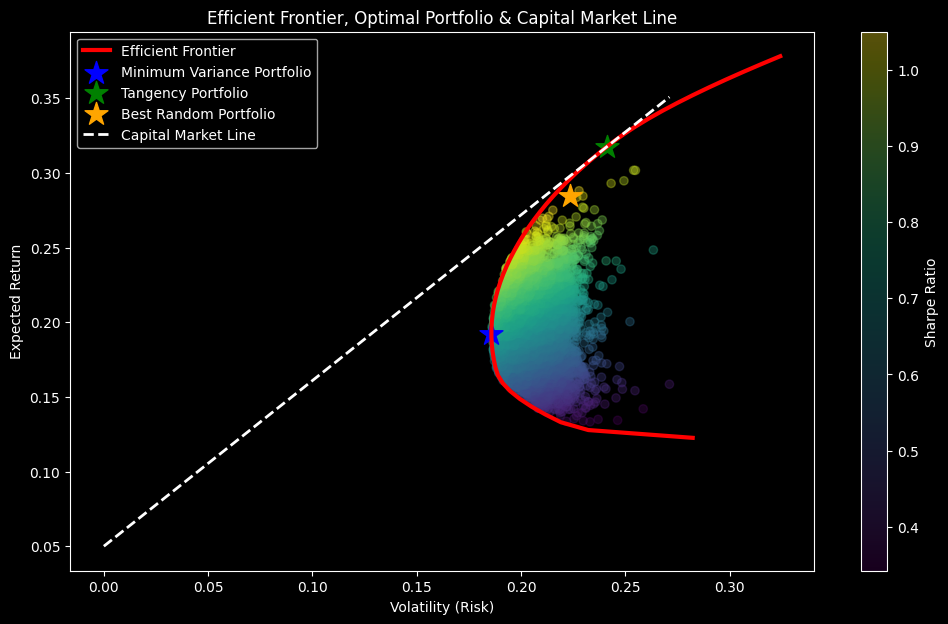

In [15]:
plt.figure(figsize=(12,7))

scatter = plt.scatter(
    risk_list,
    returns_list,
    c=sharpe_list,
    cmap="viridis",
    alpha=0.35
)

plt.colorbar(scatter,label="Sharpe Ratio")

plt.plot(
    frontier_risk,
    target_returns,
    color="red",
    linewidth=3,
    label="Efficient Frontier"
)

plt.scatter(
    min_var_vol,
    min_var_return,
    color="blue",
    marker="*",
    s=300,
    label="Minimum Variance Portfolio"
)

plt.scatter(
    tangency_vol,
    tangency_return,
    color="green",
    marker="*",
    s=300,
    label="Tangency Portfolio"
)

plt.scatter(
    best_random_risk,
    best_random_return,
    color="orange",
    marker="*",
    s=300,
    label="Best Random Portfolio"
)

plt.plot(
    cml_x,
    cml_y,
    color="white",
    linestyle="--",
    linewidth=2,
    label="Capital Market Line"
)

plt.xlabel("Volatility (Risk)")
plt.ylabel("Expected Return")

plt.title("Efficient Frontier, Optimal Portfolio & Capital Market Line")

plt.legend()

plt.show()

In [23]:
plt.savefig("efficient_frontier.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [16]:
print("Minimum Variance Portfolio Weights\n")

for stock, weight in zip(stocks, optimal_weights):
    print(f"{stock}: {weight:.3f}")

Minimum Variance Portfolio Weights

MODEFENCE.NS: 0.101
CUMMINSIND.NS: 0.094
POLYCAB.NS: 0.243
M&M.NS: 0.146
INDIANB.NS: 0.336
MON100.NS: 0.080


In [17]:
print("\nTangency Portfolio Weights\n")

for stock, weight in zip(stocks, sharpe_weights):
    print(f"{stock}: {weight:.3f}")


Tangency Portfolio Weights

MODEFENCE.NS: 0.000
CUMMINSIND.NS: 0.605
POLYCAB.NS: 0.007
M&M.NS: 0.000
INDIANB.NS: 0.388
MON100.NS: 0.000


In [18]:
train_returns = returns.loc["2022":"2023"]
test_returns = returns.loc["2024":]

In [19]:
mu_train = train_returns.mean() * 252
cov_train = train_returns.cov() * 252

c:\Users\arnaa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:576: RuntimeWarning: Mean of empty slice
  avg = a.mean(axis, **keepdims_kw)
c:\Users\arnaa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\arnaa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\frame.py:13284: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
c:\Users\arnaa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\arnaa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


In [20]:
portfolio_test_returns = test_returns @ optimal_weights

equal_weights = np.ones(n) / n
equal_test_returns = test_returns @ equal_weights

In [21]:
portfolio_cum = (1 + portfolio_test_returns).cumprod()
equal_cum = (1 + equal_test_returns).cumprod()

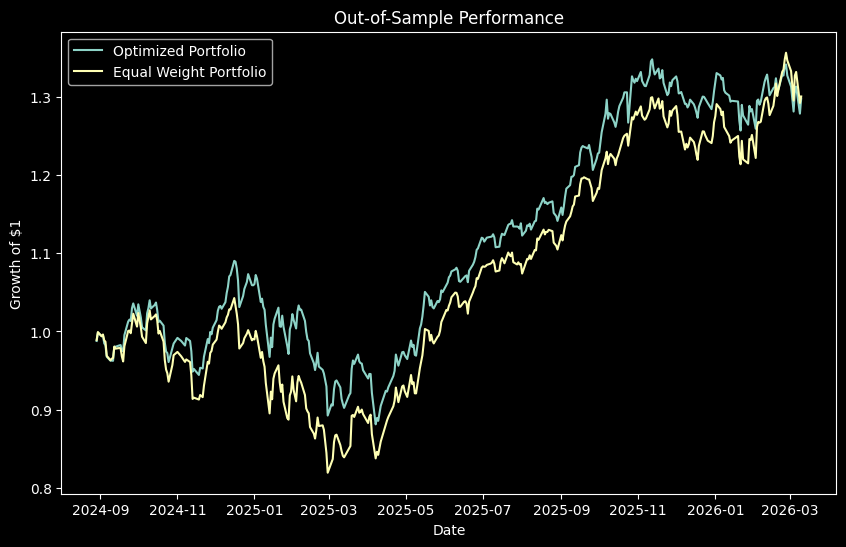

In [22]:
plt.figure(figsize=(10,6))

plt.plot(portfolio_cum,label="Optimized Portfolio")
plt.plot(equal_cum,label="Equal Weight Portfolio")

plt.title("Out-of-Sample Performance")

plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()

plt.show()